<a href="https://colab.research.google.com/github/safiullinrashid/computer-vision-/blob/main/lab_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving face.jpg to face.jpg


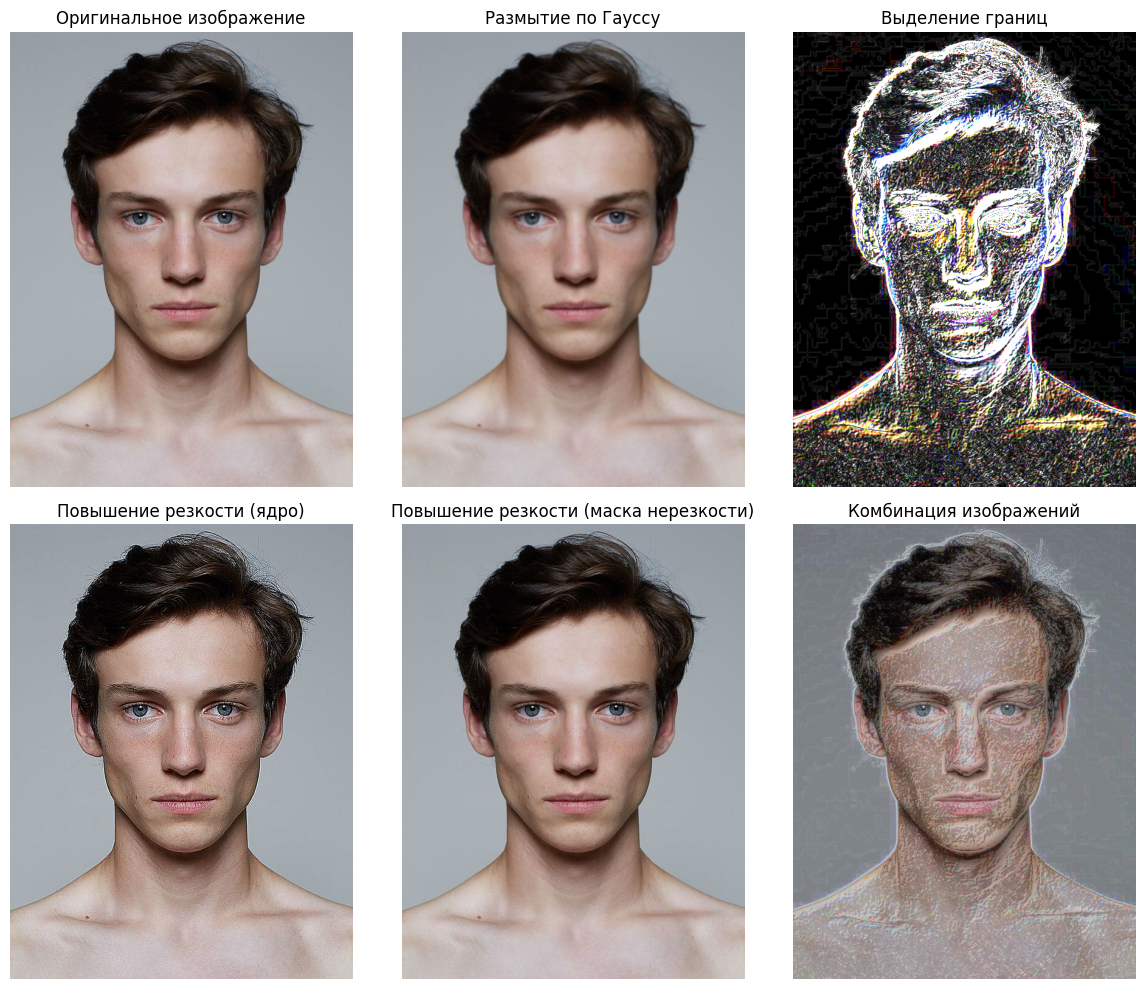

In [1]:
# Установка библиотек (если они еще не установлены)
!pip install opencv-python-headless matplotlib

# Импорт необходимых библиотек
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 1. Загрузка изображения
uploaded = files.upload()  # Выберите файл изображения
image_path = list(uploaded.keys())[0]  # Получаем имя загруженного файла
image = cv2.imread(image_path)  # Загружаем изображение с помощью OpenCV

# 2. Применение Гауссова размытия
blurred = cv2.GaussianBlur(image, (5, 5), 0)

# 3. Повышение резкости
# 3.1 С использованием ядра
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
sharpened_kernel = cv2.filter2D(image, -1, kernel)

# 3.2 С использованием маски нерезкости
sharpened_unsharp = cv2.addWeighted(image, 1.5, blurred, -0.5, 0)

# 4. Выделение границ с использованием оператора Собеля
edges_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
edges_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
edges = cv2.addWeighted(edges_x, 0.5, edges_y, 0.5, 0)
edges = cv2.convertScaleAbs(edges)

# 5. Комбинирование результатов
combined = cv2.addWeighted(blurred, 0.5, edges, 0.5, 0)
combined = cv2.addWeighted(combined, 0.5, sharpened_unsharp, 0.5, 0)

# 6. Отображение результатов
def show_images(original, blurred, edges, sharpened, combined):
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 3, 1)
    plt.title('Оригинальное изображение')
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.title('Размытие по Гауссу')
    plt.imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.title('Выделение границ')
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.title('Повышение резкости (ядро)')
    plt.imshow(cv2.cvtColor(sharpened_kernel, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.title('Повышение резкости (маска нерезкости)')
    plt.imshow(cv2.cvtColor(sharpened_unsharp, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.title('Комбинация изображений')
    plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Вызов функции для отображения результатов
show_images(image, blurred, edges, sharpened_unsharp, combined)